### Step 0. Initialize paths and collect image metadata

This section sets up the input and output directories for evaluation and collects image metadata from the **original**, **unlearned**, and **relearned_150** folders.

The `collect_images()` function reads all `.png` files, extracts the numeric image index from each filename, and stores the image index, model type, image path, and filename in a structured format.

All records are then merged into a single DataFrame and sorted, so the images can be correctly matched across the three model settings in later evaluation steps.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import re
import random
from pathlib import Path
import pandas as pd
from PIL import Image, ImageDraw

BASE_DIR = "/content/drive/MyDrive/evaluation"
OUT_DIR = "/content/drive/MyDrive/style_relearning_eval_blind_150"

ORIGINAL_DIR = f"{BASE_DIR}/original-150"
UNLEARNED_DIR = f"{BASE_DIR}/unlearned-150"
RELEARNED_DIR = f"{BASE_DIR}/relearned-150"

PANEL_DIR = f"{OUT_DIR}/blind_panels"
os.makedirs(PANEL_DIR, exist_ok=True)

def collect_images(folder, model_type):
    rows = []
    for p in sorted(Path(folder).glob("*.png")):
        m = re.search(r"^(\d+)_", p.name)
        if not m:
            continue
        rows.append({
            "image_idx": int(m.group(1)),
            "model_type": model_type,
            "image_path": str(p),
            "filename": p.name
        })
    return rows

rows = []
rows += collect_images(ORIGINAL_DIR, "original")
rows += collect_images(UNLEARNED_DIR, "unlearned")
rows += collect_images(RELEARNED_DIR, "relearned_150")

meta_df = pd.DataFrame(rows).sort_values(["image_idx", "model_type"]).reset_index(drop=True)
meta_df.head()

Mounted at /content/drive


,image_idx,model_type,image_path,filename
0,0,original,/content/drive/MyDrive/evaluation/original-150...,000_seed2219.png
1,0,relearned_150,/content/drive/MyDrive/evaluation/relearned-15...,000_seed2219.png
2,0,unlearned,/content/drive/MyDrive/evaluation/unlearned-15...,000_seed2219.png
3,1,original,/content/drive/MyDrive/evaluation/original-150...,001_seed4965.png
4,1,relearned_150,/content/drive/MyDrive/evaluation/relearned-15...,001_seed4965.png


### Section 1. Build metadata

This step organizes the three image sets into one metadata table.  
Each row stores the image index, model type, image path, and filename.  
The table is then sorted and saved for later evaluation steps.

In [ ]:
random.seed(42)

def build_blind_panel(img_paths, save_path):
    imgs = [Image.open(p).convert("RGB") for p in img_paths]
    w, h = imgs[0].size
    canvas = Image.new("RGB", (w * 3, h), color="white")
    for i, img in enumerate(imgs):
        canvas.paste(img, (i * w, 0))
    canvas.save(save_path)

panel_rows = []

for idx in sorted(meta_df["image_idx"].unique()):
    sub = meta_df[meta_df["image_idx"] == idx].copy()

    records = sub[["model_type", "image_path"]].to_dict("records")
    random.shuffle(records)

    ordered_paths = [r["image_path"] for r in records]
    ordered_models = [r["model_type"] for r in records]

    save_path = f"{PANEL_DIR}/panel_{idx:03d}.png"
    build_blind_panel(ordered_paths, save_path)

    panel_rows.append({
        "image_idx": idx,
        "panel_path": save_path,
        "left_model": ordered_models[0],
        "middle_model": ordered_models[1],
        "right_model": ordered_models[2],
        "left_path": ordered_paths[0],
        "middle_path": ordered_paths[1],
        "right_path": ordered_paths[2],
    })

panel_df = pd.DataFrame(panel_rows)
mapping_path = f"{OUT_DIR}/blind_panel_mapping.csv"
panel_df.to_csv(mapping_path, index=False)

print(panel_df.head())
print("Saved mapping to:", mapping_path)

   image_idx                                         panel_path  \
0          0  /content/drive/MyDrive/style_relearning_eval_b...   
1          1  /content/drive/MyDrive/style_relearning_eval_b...   
2          2  /content/drive/MyDrive/style_relearning_eval_b...   
3          3  /content/drive/MyDrive/style_relearning_eval_b...   
4          4  /content/drive/MyDrive/style_relearning_eval_b...   

      left_model   middle_model right_model  \
0  relearned_150       original   unlearned   
1      unlearned  relearned_150    original   
2  relearned_150      unlearned    original   
3  relearned_150      unlearned    original   
4  relearned_150       original   unlearned   

                                           left_path  \
0  /content/drive/MyDrive/evaluation/relearned-15...   
1  /content/drive/MyDrive/evaluation/unlearned-15...   
2  /content/drive/MyDrive/evaluation/relearned-15...   
3  /content/drive/MyDrive/evaluation/relearned-15...   
4  /content/drive/MyDrive/evaluati

### Section 2. Define the blind LLM evaluation prompt

This step creates the prompt for blind evaluation.  
The LLM compares three shuffled images labeled as **left**, **middle**, and **right**, without knowing their true model identities.

It returns style scores, most/least Van Gogh-like judgments, relearning status, confidence, and a short reason for each panel.

In [ ]:
LLM_EVAL_PROMPT_BLIND = """
You are evaluating artistic style relearning in generated images.

You will be shown three images with the same content identity.
They are arranged from left to right as:
- left
- middle
- right

Do not assume which image is original, unlearned, or relearned.
Judge only based on visual appearance.

Focus on:
- painterly color relationships
- expressive brushstroke-like texture
- composition patterns
- motif-level Van Gogh-like style traits

Please answer in the following format:

1. left_style_score: [1-5]
2. middle_style_score: [1-5]
3. right_style_score: [1-5]

4. which_image_looks_most_like_van_gogh:
- left
- middle
- right

5. which_image_looks_least_like_van_gogh:
- left
- middle
- right

6. relearning_status:
- not relearned
- partially relearned
- clearly relearned

7. confidence:
- low
- medium
- high

8. short_reason:
Write 2-4 sentences.

Scoring guide:
1 = almost no Van Gogh-like style
2 = weak
3 = moderate
4 = strong
5 = very strong
"""
print(LLM_EVAL_PROMPT_BLIND)


You are evaluating artistic style relearning in generated images.

You will be shown three images with the same content identity.
They are arranged from left to right as:
- left
- middle
- right

Do not assume which image is original, unlearned, or relearned.
Judge only based on visual appearance.

Focus on:
- painterly color relationships
- expressive brushstroke-like texture
- composition patterns
- motif-level Van Gogh-like style traits

Please answer in the following format:

1. left_style_score: [1-5]
2. middle_style_score: [1-5]
3. right_style_score: [1-5]

4. which_image_looks_most_like_van_gogh:
- left
- middle
- right

5. which_image_looks_least_like_van_gogh:
- left
- middle
- right

6. relearning_status:
- not relearned
- partially relearned
- clearly relearned

7. confidence:
- low
- medium
- high

8. short_reason:
Write 2-4 sentences.

Scoring guide:
1 = almost no Van Gogh-like style
2 = weak
3 = moderate
4 = strong
5 = very strong



Number of panels: 30
   image_idx                                         panel_path  \
0          0  /content/drive/MyDrive/style_relearning_eval_b...   
1          1  /content/drive/MyDrive/style_relearning_eval_b...   
2          2  /content/drive/MyDrive/style_relearning_eval_b...   
3          3  /content/drive/MyDrive/style_relearning_eval_b...   
4          4  /content/drive/MyDrive/style_relearning_eval_b...   

      left_model   middle_model right_model  \
0  relearned_150       original   unlearned   
1      unlearned  relearned_150    original   
2  relearned_150      unlearned    original   
3  relearned_150      unlearned    original   
4  relearned_150       original   unlearned   

                                           left_path  \
0  /content/drive/MyDrive/evaluation/relearned-15...   
1  /content/drive/MyDrive/evaluation/unlearned-15...   
2  /content/drive/MyDrive/evaluation/relearned-15...   
3  /content/drive/MyDrive/evaluation/relearned-15...   
4  /content/d

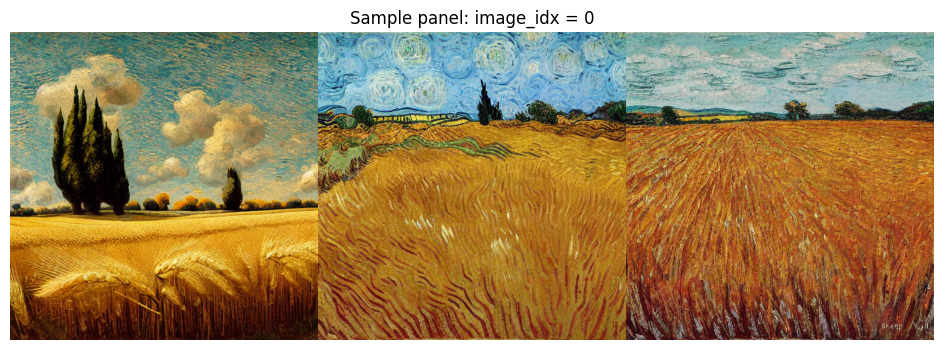

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

print("Number of panels:", len(panel_df))
print(panel_df.head())

sample_path = panel_df.iloc[0]["panel_path"]
sample_img = Image.open(sample_path)

plt.figure(figsize=(12, 4))
plt.imshow(sample_img)
plt.axis("off")
plt.title(f"Sample panel: image_idx = {panel_df.iloc[0]['image_idx']}")
plt.show()

In [ ]:
RESULTS_TEMPLATE_PATH = f"{OUT_DIR}/llm_blind_results_template.csv"

results_template = pd.DataFrame({
    "image_idx": panel_df["image_idx"],
    "panel_path": panel_df["panel_path"],
    "left_style_score": None,
    "middle_style_score": None,
    "right_style_score": None,
    "which_image_looks_most_like_van_gogh": None,
    "which_image_looks_least_like_van_gogh": None,
    "relearning_status": None,
    "confidence": None,
    "short_reason": None
})

results_template.to_csv(RESULTS_TEMPLATE_PATH, index=False)
print("Saved:", RESULTS_TEMPLATE_PATH)
results_template.head()

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/llm_blind_results_template.csv


,image_idx,panel_path,left_style_score,middle_style_score,right_style_score,which_image_looks_most_like_van_gogh,which_image_looks_least_like_van_gogh,relearning_status,confidence,short_reason
0,0,/content/drive/MyDrive/style_relearning_eval_b...,None,None,None,None,None,None,None,None
1,1,/content/drive/MyDrive/style_relearning_eval_b...,None,None,None,None,None,None,None,None
2,2,/content/drive/MyDrive/style_relearning_eval_b...,None,None,None,None,None,None,None,None
3,3,/content/drive/MyDrive/style_relearning_eval_b...,None,None,None,None,None,None,None,None
4,4,/content/drive/MyDrive/style_relearning_eval_b...,None,None,None,None,None,None,None,None


In [ ]:
import pandas as pd

RESULTS_TEMPLATE_PATH = f"{OUT_DIR}/llm_blind_results_template.csv"
RESULTS_PATH = f"{OUT_DIR}/llm_blind_results.csv"

results_df = pd.read_csv(RESULTS_TEMPLATE_PATH)

new_results = [
    {
        "image_idx": 0,
        "left_style_score": 3,
        "middle_style_score": 5,
        "right_style_score": 4,
        "which_image_looks_most_like_van_gogh": "middle",
        "which_image_looks_least_like_van_gogh": "left",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The middle image shows strong Van Gogh-like traits, especially in the swirling sky, dynamic brushstrokes, and exaggerated texture in the wheat field. The right image also captures expressive strokes and color intensity but is slightly more structured and less dynamic. The left image appears more restrained, with smoother textures and more realistic rendering, lacking the signature energetic brushwork."
    },
    {
        "image_idx": 1,
        "left_style_score": 4,
        "middle_style_score": 5,
        "right_style_score": 5,
        "which_image_looks_most_like_van_gogh": "middle",
        "which_image_looks_least_like_van_gogh": "left",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The middle image strongly exhibits Van Gogh's dynamic brushwork, especially in the swirling background and expressive tree forms. The right image also captures hallmark traits like bold outlines, high contrast colors, and stylized blossoms, though it feels slightly more graphic. The left image is closer to traditional still-life painting with softer textures and less exaggerated brushstroke energy."
    },
    {
        "image_idx": 2,
        "left_style_score": 4,
        "middle_style_score": 2,
        "right_style_score": 5,
        "which_image_looks_most_like_van_gogh": "right",
        "which_image_looks_least_like_van_gogh": "middle",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The right image has the strongest Van Gogh-like traits, with bold outlines, exaggerated color contrast, tilted perspective, and expressive floor strokes. The left image also shows similar composition and warm color relationships, but it feels smoother and more digitally cleaned. The middle image is much softer and more muted, with weaker brushstroke texture and less stylized structure."
    },
    {
        "image_idx": 3,
        "left_style_score": 2,
        "middle_style_score": 2,
        "right_style_score": 5,
        "which_image_looks_most_like_van_gogh": "right",
        "which_image_looks_least_like_van_gogh": "middle",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The right image has very strong Van Gogh-like traits, especially the swirling sky, bold color contrast, and expressive directional brushstrokes in the water. The left and middle images are much more muted and realistic, with smoother textures and weaker stylization. The middle image looks the least Van Gogh-like because it has the softest color relationships and least energetic brushwork."
    },
    {
        "image_idx": 4,
        "left_style_score": 4,
        "middle_style_score": 5,
        "right_style_score": 3,
        "which_image_looks_most_like_van_gogh": "middle",
        "which_image_looks_least_like_van_gogh": "right",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The middle image has the strongest Van Gogh-like traits, especially the intense blue-yellow-green contrast, bold outlines, and exaggerated perspective. The left image also shows strong expressive texture and café-at-night color relationships, but it is slightly more controlled. The right image is more muted and soft, with weaker brushstroke energy and less dramatic color contrast."
    }
]

for item in new_results:
    idx = item["image_idx"]
    for key, value in item.items():
        if key != "image_idx":
            results_df.loc[results_df["image_idx"] == idx, key] = value

results_df.to_csv(RESULTS_PATH, index=False)

print("Saved:", RESULTS_PATH)
print(results_df[results_df["image_idx"].isin([0,1,2,3,4])])

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/llm_blind_results.csv
   image_idx                                         panel_path  \
0          0  /content/drive/MyDrive/style_relearning_eval_b...   
1          1  /content/drive/MyDrive/style_relearning_eval_b...   
2          2  /content/drive/MyDrive/style_relearning_eval_b...   
3          3  /content/drive/MyDrive/style_relearning_eval_b...   
4          4  /content/drive/MyDrive/style_relearning_eval_b...   

   left_style_score  middle_style_score  right_style_score  \
0               3.0                 5.0                4.0   
1               4.0                 5.0                5.0   
2               4.0                 2.0                5.0   
3               2.0                 2.0                5.0   
4               4.0                 5.0                3.0   

  which_image_looks_most_like_van_gogh which_image_looks_least_like_van_gogh  \
0                               middle                      

/tmp/ipykernel_10629/2660093510.py:70: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'middle' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results_df.loc[results_df["image_idx"] == idx, key] = value
/tmp/ipykernel_10629/2660093510.py:70: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'left' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results_df.loc[results_df["image_idx"] == idx, key] = value
/tmp/ipykernel_10629/2660093510.py:70: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'clearly relearned' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results_df.loc[results_df["image_idx"] == idx, key] = value
/tmp/ipyke

In [ ]:
import pandas as pd

RESULTS_PATH = f"{OUT_DIR}/llm_blind_results.csv"
results_df = pd.read_csv(RESULTS_PATH)

new_results = [
    {
        "image_idx": 5,
        "left_style_score": 5,
        "middle_style_score": 4,
        "right_style_score": 1,
        "which_image_looks_most_like_van_gogh": "left",
        "which_image_looks_least_like_van_gogh": "right",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The left image has very strong Van Gogh-like traits, especially the swirling sky, intense blue-yellow contrast, and expressive cypress brushwork. The middle image also shows strong painterly texture and Van Gogh-like color relationships, but it is less iconic and slightly more blended. The right image is monochrome and sketch-like, with almost none of the color or brushstroke qualities associated with Van Gogh."
    },
    {
        "image_idx": 6,
        "left_style_score": 4,
        "middle_style_score": 2,
        "right_style_score": 5,
        "which_image_looks_most_like_van_gogh": "right",
        "which_image_looks_least_like_van_gogh": "middle",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The right image shows the strongest Van Gogh-like traits, with expressive directional brushstrokes, blue-yellow color contrast, and textured field patterns. The left image also has strong painterly texture and warm landscape colors, but it is darker and less iconic. The middle image feels more like a framed traditional landscape, with weaker brushstroke energy and less Van Gogh-like color intensity."
    },
    {
        "image_idx": 7,
        "left_style_score": 4,
        "middle_style_score": 1,
        "right_style_score": 5,
        "which_image_looks_most_like_van_gogh": "right",
        "which_image_looks_least_like_van_gogh": "middle",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The right image has the strongest Van Gogh-like traits, especially the swirling sky, intense blue-yellow contrast, and energetic field brushstrokes. The left image also shows painterly texture and warm landscape colors, but it is less expressive. The middle image is mostly sketch-like and muted, with very weak Van Gogh-like color and brushstroke qualities."
    },
    {
        "image_idx": 8,
        "left_style_score": 3,
        "middle_style_score": 3,
        "right_style_score": 5,
        "which_image_looks_most_like_van_gogh": "right",
        "which_image_looks_least_like_van_gogh": "left",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The right image has the strongest Van Gogh-like style, with bold outlines, clearer directional water strokes, and stronger blue-green color contrast. The middle image has similar composition but is softer and less expressive. The left image is painterly but more realistic and less stylized, so it looks least Van Gogh-like."
    },
    {
        "image_idx": 9,
        "left_style_score": 4,
        "middle_style_score": 5,
        "right_style_score": 3,
        "which_image_looks_most_like_van_gogh": "middle",
        "which_image_looks_least_like_van_gogh": "right",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The middle image has the strongest Van Gogh-like traits, especially the swirling sky, rhythmic field strokes, and intense yellow-blue color contrast. The left image also shows expressive texture and strong color relationships, but it feels slightly more polished. The right image is more muted and realistic, with weaker brushstroke energy."
    }
]

for item in new_results:
    idx = item["image_idx"]
    for key, value in item.items():
        if key != "image_idx":
            results_df.loc[results_df["image_idx"] == idx, key] = value

results_df.to_csv(RESULTS_PATH, index=False)

print("Saved:", RESULTS_PATH)
print(results_df[results_df["image_idx"].isin([5,6,7,8,9])])

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/llm_blind_results.csv
   image_idx                                         panel_path  \
5          5  /content/drive/MyDrive/style_relearning_eval_b...   
6          6  /content/drive/MyDrive/style_relearning_eval_b...   
7          7  /content/drive/MyDrive/style_relearning_eval_b...   
8          8  /content/drive/MyDrive/style_relearning_eval_b...   
9          9  /content/drive/MyDrive/style_relearning_eval_b...   

   left_style_score  middle_style_score  right_style_score  \
5               5.0                 4.0                1.0   
6               4.0                 2.0                5.0   
7               4.0                 1.0                5.0   
8               3.0                 3.0                5.0   
9               4.0                 5.0                3.0   

  which_image_looks_most_like_van_gogh which_image_looks_least_like_van_gogh  \
5                                 left                      

In [ ]:
import pandas as pd

RESULTS_PATH = f"{OUT_DIR}/llm_blind_results.csv"
results_df = pd.read_csv(RESULTS_PATH)

new_results = [
    {
        "image_idx": 10,
        "left_style_score": 5,
        "middle_style_score": 3,
        "right_style_score": 2,
        "which_image_looks_most_like_van_gogh": "left",
        "which_image_looks_least_like_van_gogh": "right",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The left image has the strongest Van Gogh-like traits, with dense directional brushstrokes, bold outlines, and intense yellow-blue-green color relationships. The middle image keeps some Van Gogh-like countryside composition and warm color, but it looks smoother and more illustrative. The right image is muted and sketch-like, with weaker color contrast and much less expressive brushwork."
    },
    {
        "image_idx": 11,
        "left_style_score": 2,
        "middle_style_score": 3,
        "right_style_score": 5,
        "which_image_looks_most_like_van_gogh": "right",
        "which_image_looks_least_like_van_gogh": "left",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The right image has the strongest Van Gogh-like traits, with bold outlines, textured yellow background, and expressive flower shapes. The middle image has strong blue-yellow color contrast but looks smoother and more digitally polished. The left image is more realistic and framed, with weaker brushstroke texture and less stylized color."
    },
    {
        "image_idx": 12,
        "left_style_score": 5,
        "middle_style_score": 4,
        "right_style_score": 2,
        "which_image_looks_most_like_van_gogh": "left",
        "which_image_looks_least_like_van_gogh": "right",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The left image shows very strong Van Gogh-like traits, especially the bold outlines, flattened portrait style, and turquoise background strokes. The middle image also has Van Gogh-like village colors and textured ground patterns, but it is less iconic. The right image is much softer and more muted, with weaker outlines and less expressive brushwork."
    },
    {
        "image_idx": 13,
        "left_style_score": 3,
        "middle_style_score": 2,
        "right_style_score": 5,
        "which_image_looks_most_like_van_gogh": "right",
        "which_image_looks_least_like_van_gogh": "middle",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The right image has the strongest Van Gogh-like traits, with bold outlines, intense yellow-green contrast, and rhythmic field brushstrokes. The left image has some painterly texture but feels more restrained. The middle image is muted and less expressive, with weaker color contrast and less clear directional brushwork."
    },
    {
        "image_idx": 14,
        "left_style_score": 5,
        "middle_style_score": 3,
        "right_style_score": 1,
        "which_image_looks_most_like_van_gogh": "left",
        "which_image_looks_least_like_van_gogh": "right",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The left image has very strong Van Gogh-like traits, especially the swirling sky, repeated circular stars, and expressive tree outlines. The middle image keeps some painterly texture but is calmer and more realistic. The right image is monochrome and sketch-like, lacking Van Gogh-like color contrast and energetic brushwork."
    }
]

for item in new_results:
    idx = item["image_idx"]
    for key, value in item.items():
        if key != "image_idx":
            results_df.loc[results_df["image_idx"] == idx, key] = value

results_df.to_csv(RESULTS_PATH, index=False)

print("Saved:", RESULTS_PATH)
print(results_df[results_df["image_idx"].isin([10,11,12,13,14])])

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/llm_blind_results.csv
    image_idx                                         panel_path  \
10         10  /content/drive/MyDrive/style_relearning_eval_b...   
11         11  /content/drive/MyDrive/style_relearning_eval_b...   
12         12  /content/drive/MyDrive/style_relearning_eval_b...   
13         13  /content/drive/MyDrive/style_relearning_eval_b...   
14         14  /content/drive/MyDrive/style_relearning_eval_b...   

    left_style_score  middle_style_score  right_style_score  \
10               5.0                 3.0                2.0   
11               2.0                 3.0                5.0   
12               5.0                 4.0                2.0   
13               3.0                 2.0                5.0   
14               5.0                 3.0                1.0   

   which_image_looks_most_like_van_gogh which_image_looks_least_like_van_gogh  \
10                                 left        

In [ ]:
import pandas as pd

RESULTS_PATH = f"{OUT_DIR}/llm_blind_results.csv"
results_df = pd.read_csv(RESULTS_PATH)

new_results = [
    {
        "image_idx": 20,
        "left_style_score": 5,
        "middle_style_score": 2,
        "right_style_score": 3,
        "which_image_looks_most_like_van_gogh": "left",
        "which_image_looks_least_like_van_gogh": "middle",
        "relearning_status": "partially relearned",
        "confidence": "high",
        "short_reason": "The left image strongly captures Van Gogh-like style with vivid color contrasts, rhythmic brushstroke patterns, and expressive sky textures. The middle image is mostly line-based and lacks painterly color and texture, making it least aligned. The right image has some stylization and color warmth, but the brushwork and structure feel more photographic than painterly."
    },
    {
        "image_idx": 21,
        "left_style_score": 1,
        "middle_style_score": 3,
        "right_style_score": 5,
        "which_image_looks_most_like_van_gogh": "right",
        "which_image_looks_least_like_van_gogh": "left",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The right image has very strong Van Gogh-like traits, especially the vivid blue background, heavy outlined facial features, and expressive directional brushstrokes. The left image is photographic and monochrome, with almost no painterly style. The middle image has some painted texture, but it is smoother and more realistic than Van Gogh-like."
    },
    {
        "image_idx": 22,
        "left_style_score": 2,
        "middle_style_score": 5,
        "right_style_score": 2,
        "which_image_looks_most_like_van_gogh": "middle",
        "which_image_looks_least_like_van_gogh": "right",
        "relearning_status": "partially relearned",
        "confidence": "high",
        "short_reason": "The middle image has very strong Van Gogh-like traits, especially the swirling sky, bright blue-yellow contrast, and energetic brushstroke texture. The left image is painterly but more realistic and dark-toned. The right image is mostly monochrome sketch-like, so it lacks Van Gogh-like color relationships."
    },
    {
        "image_idx": 23,
        "left_style_score": 3,
        "middle_style_score": 5,
        "right_style_score": 4,
        "which_image_looks_most_like_van_gogh": "middle",
        "which_image_looks_least_like_van_gogh": "left",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The middle image has the strongest Van Gogh-like traits, especially the blue-yellow contrast, radiating brushstrokes, and stylized figure outline. The right image is also strongly Van Gogh-like, but slightly more silhouette-heavy. The left image is painterly but flatter and less expressive in its brushstroke structure."
    },
    {
        "image_idx": 24,
        "left_style_score": 5,
        "middle_style_score": 5,
        "right_style_score": 1,
        "which_image_looks_most_like_van_gogh": "left",
        "which_image_looks_least_like_van_gogh": "right",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "Both left and middle strongly show Van Gogh-like night-scene traits, especially the intense blue-yellow contrast, bright star motifs, and reflected light on water. The left image feels slightly more stylized and brushstroke-heavy. The right image is muted, framed, and much more photographic/realist, with almost no Van Gogh-like texture."
    }
]

for item in new_results:
    idx = item["image_idx"]
    for key, value in item.items():
        if key != "image_idx":
            results_df.loc[results_df["image_idx"] == idx, key] = value

results_df.to_csv(RESULTS_PATH, index=False)

print("Saved:", RESULTS_PATH)
print(results_df[results_df["image_idx"].isin([20,21,22,23,24])])

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/llm_blind_results.csv
    image_idx                                         panel_path  \
20         20  /content/drive/MyDrive/style_relearning_eval_b...   
21         21  /content/drive/MyDrive/style_relearning_eval_b...   
22         22  /content/drive/MyDrive/style_relearning_eval_b...   
23         23  /content/drive/MyDrive/style_relearning_eval_b...   
24         24  /content/drive/MyDrive/style_relearning_eval_b...   

    left_style_score  middle_style_score  right_style_score  \
20               5.0                 2.0                3.0   
21               1.0                 3.0                5.0   
22               2.0                 5.0                2.0   
23               3.0                 5.0                4.0   
24               5.0                 5.0                1.0   

   which_image_looks_most_like_van_gogh which_image_looks_least_like_van_gogh  \
20                                 left        

In [ ]:
import pandas as pd

RESULTS_PATH = f"{OUT_DIR}/llm_blind_results.csv"
results_df = pd.read_csv(RESULTS_PATH)

new_results = [
    {
        "image_idx": 25,
        "left_style_score": 5,
        "middle_style_score": 5,
        "right_style_score": 2,
        "which_image_looks_most_like_van_gogh": "left",
        "which_image_looks_least_like_van_gogh": "right",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The left and middle images both show very strong Van Gogh-like traits, especially swirling skies, intense blue-yellow contrast, and thick expressive strokes. The left image is slightly closer because its motifs and brush patterns resemble Van Gogh more directly. The right image is framed and decorative but much flatter and less painterly."
    },
    {
        "image_idx": 26,
        "left_style_score": 3,
        "middle_style_score": 5,
        "right_style_score": 1,
        "which_image_looks_most_like_van_gogh": "middle",
        "which_image_looks_least_like_van_gogh": "right",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The middle image has the strongest Van Gogh-like style, with sunflower motifs, textured brushwork, flattened composition, and yellow-green color relationships. The left image is somewhat painterly but smoother and less expressive. The right image is much more photographic, with little Van Gogh-like brushstroke structure."
    },
    {
        "image_idx": 27,
        "left_style_score": 3,
        "middle_style_score": 5,
        "right_style_score": 3,
        "which_image_looks_most_like_van_gogh": "middle",
        "which_image_looks_least_like_van_gogh": "left",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The middle image is strongest, with bold blue-yellow-red color blocks, thick outlines, distorted perspective, and expressive floor strokes. The left image has similar room content but feels smoother and more modern. The right image is painterly but more muted, with weaker Van Gogh-like contrast and stroke energy."
    },
    {
        "image_idx": 28,
        "left_style_score": 3,
        "middle_style_score": 4,
        "right_style_score": 5,
        "which_image_looks_most_like_van_gogh": "right",
        "which_image_looks_least_like_van_gogh": "left",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The right image has the strongest Van Gogh-like traits, with bold outlines, radiating field lines, and expressive swirling sky strokes. The middle image is also painterly but softer and less intense. The left image has some Van Gogh-like color and composition, but the texture is smoother and less expressive."
    },
    {
        "image_idx": 29,
        "left_style_score": 2,
        "middle_style_score": 5,
        "right_style_score": 3,
        "which_image_looks_most_like_van_gogh": "middle",
        "which_image_looks_least_like_van_gogh": "left",
        "relearning_status": "clearly relearned",
        "confidence": "high",
        "short_reason": "The middle image has the strongest Van Gogh-like traits, with vivid complementary colors, bold outlines, and swirling sky/ground brushstroke patterns. The left image is mostly monochrome sketch-like and lacks painterly color relationships. The right image is painterly and warm, but smoother and more illustrative than Van Gogh-like."
    }
]

for item in new_results:
    idx = item["image_idx"]
    for key, value in item.items():
        if key != "image_idx":
            results_df.loc[results_df["image_idx"] == idx, key] = value

results_df.to_csv(RESULTS_PATH, index=False)

print("Saved:", RESULTS_PATH)
print(results_df[results_df["image_idx"].isin([25,26,27,28,29])])

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/llm_blind_results.csv
    image_idx                                         panel_path  \
25         25  /content/drive/MyDrive/style_relearning_eval_b...   
26         26  /content/drive/MyDrive/style_relearning_eval_b...   
27         27  /content/drive/MyDrive/style_relearning_eval_b...   
28         28  /content/drive/MyDrive/style_relearning_eval_b...   
29         29  /content/drive/MyDrive/style_relearning_eval_b...   

    left_style_score  middle_style_score  right_style_score  \
25               5.0                 5.0                2.0   
26               3.0                 5.0                1.0   
27               3.0                 5.0                3.0   
28               3.0                 4.0                5.0   
29               2.0                 5.0                3.0   

   which_image_looks_most_like_van_gogh which_image_looks_least_like_van_gogh  \
25                                 left        

In [ ]:
import pandas as pd

BLIND_RESULTS_PATH = f"{OUT_DIR}/llm_blind_results.csv"
MAPPING_PATH = f"{OUT_DIR}/blind_panel_mapping.csv"
RESOLVED_PATH = f"{OUT_DIR}/evaluated_resolved_results.csv"

results_df = pd.read_csv(BLIND_RESULTS_PATH)
mapping_df = pd.read_csv(MAPPING_PATH)

merged = results_df.merge(mapping_df, on=["image_idx", "panel_path"], how="left")

resolved_rows = []

for _, row in merged.iterrows():
    pos_to_model = {
        "left": row["left_model"],
        "middle": row["middle_model"],
        "right": row["right_model"]
    }

    pos_to_score = {
        "left": row["left_style_score"],
        "middle": row["middle_style_score"],
        "right": row["right_style_score"]
    }

    resolved = {
        "image_idx": row["image_idx"],
        "original_style_score": None,
        "unlearned_style_score": None,
        "relearned_150_style_score": None,
        "most_van_gogh_model": pos_to_model.get(row["which_image_looks_most_like_van_gogh"], None),
        "least_van_gogh_model": pos_to_model.get(row["which_image_looks_least_like_van_gogh"], None),
        "relearning_status": row["relearning_status"],
        "confidence": row["confidence"],
        "short_reason": row["short_reason"]
    }

    for pos, model in pos_to_model.items():
        score = pos_to_score[pos]
        if model == "original":
            resolved["original_style_score"] = score
        elif model == "unlearned":
            resolved["unlearned_style_score"] = score
        elif model == "relearned_150":
            resolved["relearned_150_style_score"] = score

    resolved_rows.append(resolved)

resolved_df = pd.DataFrame(resolved_rows)
resolved_df.to_csv(RESOLVED_PATH, index=False)

print("Saved:", RESOLVED_PATH)
print(resolved_df.head())
print("Rows:", len(resolved_df))

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/evaluated_resolved_results.csv
   image_idx  original_style_score  unlearned_style_score  \
0          0                   5.0                    4.0   
1          1                   5.0                    4.0   
2          2                   5.0                    2.0   
3          3                   5.0                    2.0   
4          4                   5.0                    3.0   

   relearned_150_style_score most_van_gogh_model least_van_gogh_model  \
0                        3.0            original        relearned_150   
1                        5.0       relearned_150            unlearned   
2                        4.0            original            unlearned   
3                        2.0            original            unlearned   
4                        4.0            original            unlearned   

   relearning_status confidence  \
0  clearly relearned       high   
1  clearly relearned       high

In [ ]:
resolved_df = pd.read_csv(RESOLVED_PATH)

print("Average scores:")
print(resolved_df[[
    "original_style_score",
    "unlearned_style_score",
    "relearned_150_style_score"
]].mean())

print("\nRelearning status:")
print(resolved_df["relearning_status"].value_counts())

print("\nMost Van Gogh-like:")
print(resolved_df["most_van_gogh_model"].value_counts())

print("\nLeast Van Gogh-like:")
print(resolved_df["least_van_gogh_model"].value_counts())

Average scores:
original_style_score         5.00
unlearned_style_score        2.20
relearned_150_style_score    3.48
dtype: float64

Relearning status:
relearning_status
clearly relearned      23
partially relearned     2
Name: count, dtype: int64

Most Van Gogh-like:
most_van_gogh_model
original         24
relearned_150     1
Name: count, dtype: int64

Least Van Gogh-like:
least_van_gogh_model
unlearned        21
relearned_150     4
Name: count, dtype: int64


In [ ]:
print("Original score counts:")
print(resolved_df["original_style_score"].value_counts().sort_index())

print("\nUnlearned score counts:")
print(resolved_df["unlearned_style_score"].value_counts().sort_index())

print("\nRelearned_150 score counts:")
print(resolved_df["relearned_150_style_score"].value_counts().sort_index())

Original score counts:
original_style_score
5.0    25
Name: count, dtype: int64

Unlearned score counts:
unlearned_style_score
1.0     6
2.0    11
3.0     5
4.0     3
Name: count, dtype: int64

Relearned_150 score counts:
relearned_150_style_score
2.0     2
3.0    12
4.0     8
5.0     3
Name: count, dtype: int64


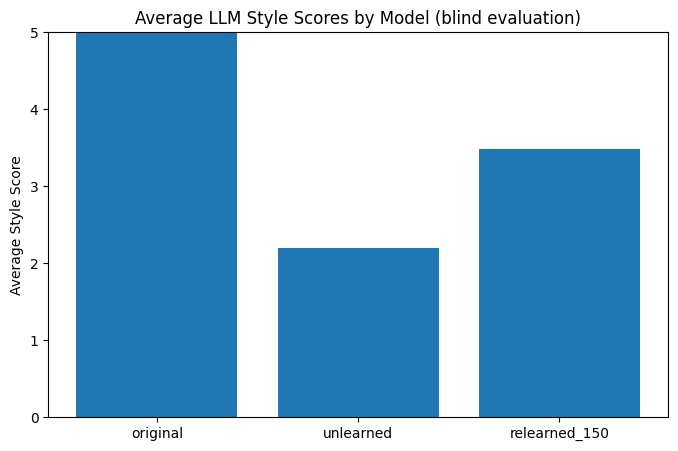

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/llm_average_scores_blind.png


In [ ]:
import matplotlib.pyplot as plt

avg_scores = resolved_df[[
    "original_style_score",
    "unlearned_style_score",
    "relearned_150_style_score"
]].mean()

labels = ["original", "unlearned", "relearned_150"]
values = [
    avg_scores["original_style_score"],
    avg_scores["unlearned_style_score"],
    avg_scores["relearned_150_style_score"]
]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.ylabel("Average Style Score")
plt.title("Average LLM Style Scores by Model (blind evaluation)")
plt.ylim(0, 5)

llm_avg_fig = f"{OUT_DIR}/llm_average_scores_blind.png"
plt.savefig(llm_avg_fig, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", llm_avg_fig)

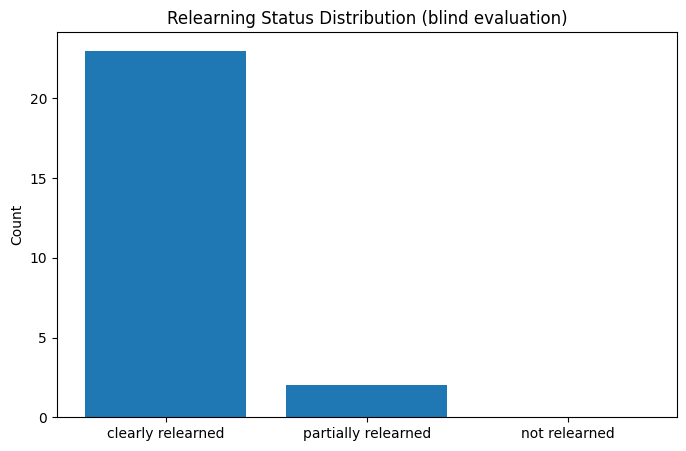

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/relearning_status_distribution_blind.png


In [ ]:
status_counts = resolved_df["relearning_status"].value_counts()
status_order = ["clearly relearned", "partially relearned", "not relearned"]
status_values = [status_counts.get(x, 0) for x in status_order]

plt.figure(figsize=(8,5))
plt.bar(status_order, status_values)
plt.ylabel("Count")
plt.title("Relearning Status Distribution (blind evaluation)")

status_fig = f"{OUT_DIR}/relearning_status_distribution_blind.png"
plt.savefig(status_fig, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", status_fig)

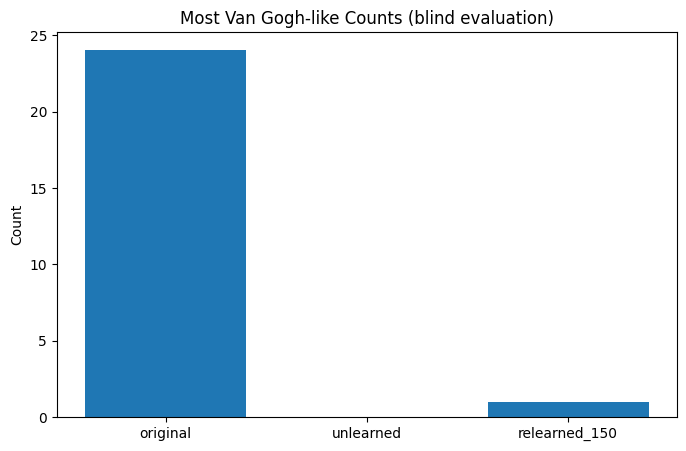

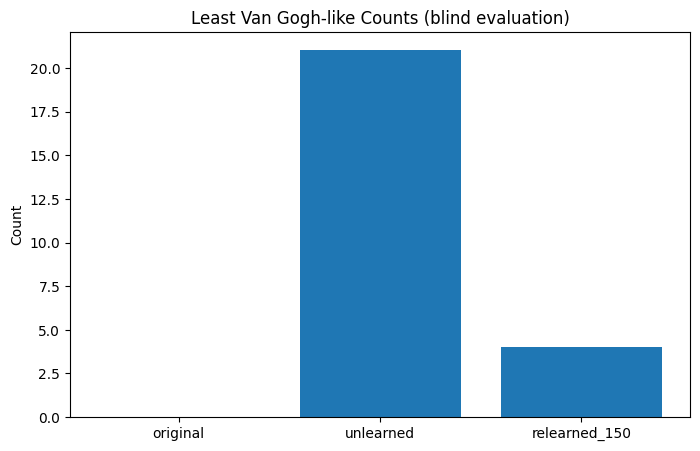

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/most_van_gogh_counts_blind.png
Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/least_van_gogh_counts_blind.png


In [ ]:
most_counts = resolved_df["most_van_gogh_model"].value_counts()
least_counts = resolved_df["least_van_gogh_model"].value_counts()

model_order = ["original", "unlearned", "relearned_150"]

most_values = [most_counts.get(x, 0) for x in model_order]
least_values = [least_counts.get(x, 0) for x in model_order]

plt.figure(figsize=(8,5))
plt.bar(model_order, most_values)
plt.ylabel("Count")
plt.title("Most Van Gogh-like Counts (blind evaluation)")
most_fig = f"{OUT_DIR}/most_van_gogh_counts_blind.png"
plt.savefig(most_fig, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

plt.figure(figsize=(8,5))
plt.bar(model_order, least_values)
plt.ylabel("Count")
plt.title("Least Van Gogh-like Counts (blind evaluation)")
least_fig = f"{OUT_DIR}/least_van_gogh_counts_blind.png"
plt.savefig(least_fig, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", most_fig)
print("Saved:", least_fig)

In [ ]:
summary_df = pd.DataFrame({
    "metric": [
        "original_mean_score",
        "unlearned_mean_score",
        "relearned_150_mean_score",
        "clearly_relearned_count",
        "partially_relearned_count",
        "not_relearned_count",
        "original_most_vangogh",
        "unlearned_most_vangogh",
        "relearned_150_most_vangogh",
        "original_least_vangogh",
        "unlearned_least_vangogh",
        "relearned_150_least_vangogh",
    ],
    "value": [
        avg_scores["original_style_score"],
        avg_scores["unlearned_style_score"],
        avg_scores["relearned_150_style_score"],
        status_counts.get("clearly relearned", 0),
        status_counts.get("partially relearned", 0),
        status_counts.get("not relearned", 0),
        most_counts.get("original", 0),
        most_counts.get("unlearned", 0),
        most_counts.get("relearned_150", 0),
        least_counts.get("original", 0),
        least_counts.get("unlearned", 0),
        least_counts.get("relearned_150", 0),
    ]
})

summary_path = f"{OUT_DIR}/llm_summary_blind.csv"
summary_df.to_csv(summary_path, index=False)
print("Saved:", summary_path)
summary_df

Saved: /content/drive/MyDrive/style_relearning_eval_blind_150/llm_summary_blind.csv


,metric,value
0,original_mean_score,5.00
1,unlearned_mean_score,2.20
2,relearned_150_mean_score,3.48
3,clearly_relearned_count,23.00
4,partially_relearned_count,2.00
5,not_relearned_count,0.00
6,original_most_vangogh,24.00
7,unlearned_most_vangogh,0.00
8,relearned_150_most_vangogh,1.00
9,original_least_vangogh,0.00
